# 9. Strange Attractors: The Shape of Chaos

Chapter 8 iterated one formula and colored how fast orbits *escaped*. Today the opposite temperament: a formula whose orbits never escape and never settle, and whose visits, collected by the million, condense into smoke-like figures that no single point of them ever drew.

## Today's destination

One formula, four numbers, forty-eight million visits. The picture below is not a drawing: nothing in it is a line, a stroke or a shape. It is a *census*. A point jumps around the plane according to a rule of two sines and two cosines, forever boxed inside a small square, never repeating; we count where it lands, and the counts, glowing by their logarithm, reveal that this restless wandering has an anatomy. The figure is called a strange attractor, and by the end of today you will be catching your own.

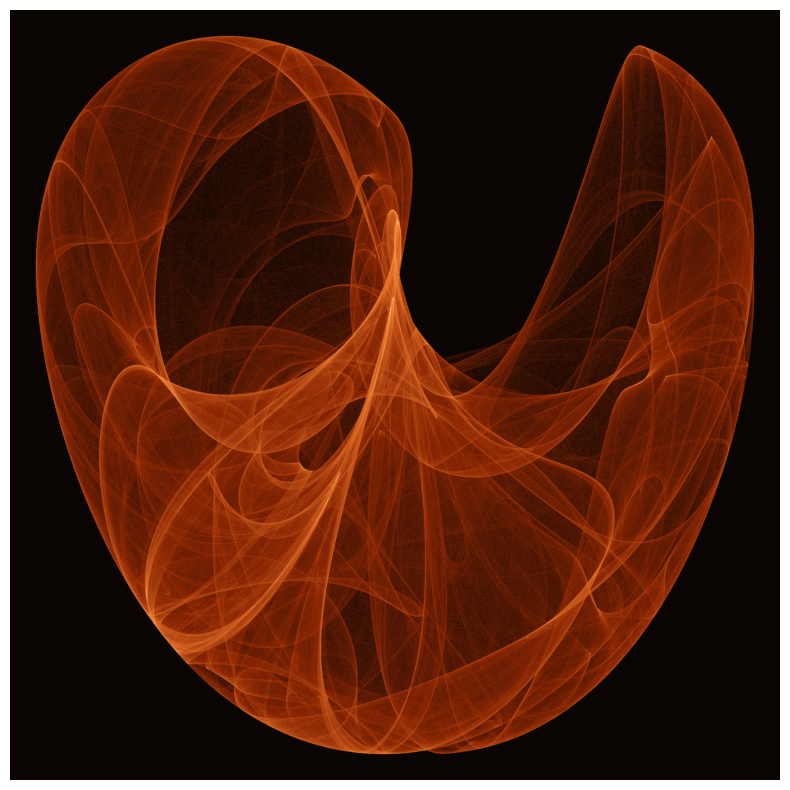

In [1]:
# display this chapter's showpiece (generated by the last cell of this notebook)
import os
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

showpiece_path = "../assets/outputs/ch09_showpiece.png"
if os.path.exists(showpiece_path):
    image = mpimg.imread(showpiece_path)
    plt.figure(figsize=(10, 10))
    plt.imshow(image)
    plt.axis("off")
    plt.show()
else:
    print("Not generated yet -- run the whole notebook once and come back.")

## Context: the weather that would not repeat

In the winter of 1961, the MIT meteorologist **Edward Lorenz** (1917-2008) was running a toy weather model on a Royal McBee LGP-30, a computer the size of a desk. Wanting to re-examine one run, he restarted it midway, typing in the numbers from a printout. The new weather tracked the old for a while, then drifted, then bore no resemblance to it at all. The cause was almost nothing: the printout showed three decimals (0.506) while the machine's memory held six (0.506127). A difference of one part in ten thousand had, within a simulated month or two, rewritten the weather of the world. Lorenz had assumed, as everyone did, that small causes have small effects; his 1963 paper "Deterministic Nonperiodic Flow" quietly reported otherwise, and with it described the first strange attractor: the butterfly-winged figure his equations traced, on which the weather wanders forever without repeating. The now-famous name arrived in 1972, when Lorenz spoke at a session titled "Does the Flap of a Butterfly's Wings in Brazil Set Off a Tornado in Texas?" (he had not supplied a title; the convener Philip Merilees coined it for him; Lorenz's own earlier image had been a seagull). *Butterfly effect* stuck, and the attractor even looks like one.

For two decades this stayed specialist knowledge. Then came the 1980s, the same decade that hung chapter 8's fractals in galleries, and chaos went public alongside them: James Gleick's bestseller *Chaos: Making a New Science* (1987) put Lorenz's story on airport bookshelves the very year Peitgen and Richter's Mandelbrot renderings were touring as *The Beauty of Fractals*. And exactly as with fractals, the home computer made chaos something you could *do*. In *Scientific American*, A. K. Dewdney's "Computer Recreations" column (1984-1991) served readers monthly recipes for mathematical pictures, and the July 1987 installment, "Probing the strange attractions of chaos", printed iteration formulas sent in by readers. One of them, from **Peter de Jong** of Leiden, is the formula this chapter is built on. Clifford Pickover's *Computers, Pattern, Chaos and Beauty* (1990) carried the genre onward, and Paul Bourke's web pages, begun in 1989 and still growing, remain the standard archive where parameter sets for these figures are traded like pressed flowers. The images in this lineage were made by amateurs on home machines, published by readers' letters: generative art's folk tradition.

Chapter 8 and today are a matched pair. There, we iterated $z^2 + c$ and asked *who leaves*: the picture was the boundary of divergence, drawn by escape times. Today nothing leaves. The de Jong map folds the whole plane into a box four units wide, and the question becomes *where does a trapped orbit spend its time*. The answer, it turns out, is not "everywhere" and not "in a loop", but a third thing, and drawing that third thing is today's work.

## The mathematics: a map instead of a walk

The rule is a **2D map** (Abbildung): a recipe that takes a point $(x, y)$ and returns the next point. The de Jong family is

$$x' = \sin(a\,y) - \cos(b\,x), \qquad y' = \sin(c\,x) - \cos(d\,y),$$

read aloud: *the new x looks only at the old y (through a sine) and the old x (through a cosine); the new y does the reverse.* The four numbers $a, b, c, d$ are the artwork's entire genome. Note what the formula promises before we run anything: sines and cosines only ever return values between $-1$ and $1$, so each coordinate is always the difference of two such values, trapped between $-2$ and $2$ forever. **No orbit can escape.** Chapter 8's question (who flees to infinity?) is settled in advance; the mystery moves inside the box.

Iterating is the same mindset as chapter 8, with one honest difference: there we could iterate every pixel of a grid because each pixel asked its own question. Here there is no grid and no pixel, just one orbit hopping through continuous space, so we begin the way chapter 1 began its walks: a plain loop, one step at a time.

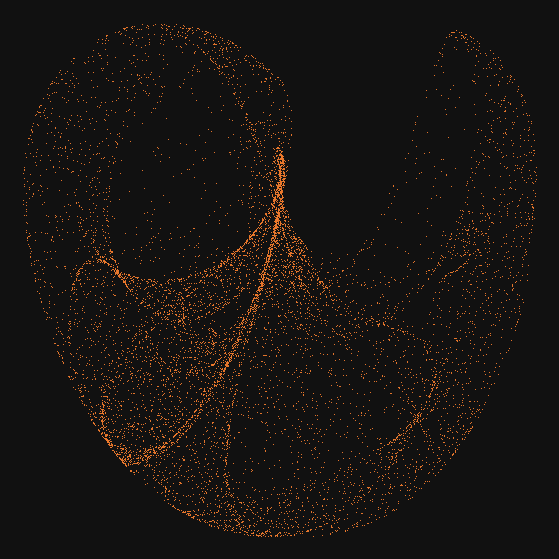

In [2]:
# one orbit of the de Jong map: a plain loop, ten thousand hops
import sys
import numpy as np

sys.path.append("..")                       # make the course package importable
from agap.helpers import PAPER, PALETTES, save_artwork

a, b, c, d = 1.4, -2.3, 2.4, -2.1           # the chapter's house parameters

x, y = 0.1, 0.1
points = []
for _ in range(10_000):
    x, y = np.sin(a * y) - np.cos(b * x), np.sin(c * x) - np.cos(d * y)
    points.append((x, y))
points = np.array(points)

fig, ax = plt.subplots(figsize=(7, 7), facecolor="#111111")
ax.scatter(points[:, 0], points[:, 1], s=0.5, color="#F07B2D", linewidths=0)
ax.set_facecolor("#111111")
ax.set_xlim(-2.1, 2.1)
ax.set_ylim(-2.1, 2.1)
ax.set_aspect("equal")
ax.axis("off")
plt.show()

Ten thousand hops, and the figure is already there: sweeping veils, dense seams, deliberate empty bays. Watch what did *not* happen. The orbit did not fill the box uniformly, though it was free to; it did not settle into a repeating loop, though nothing forbade that either. It visits only a particular filigree subset of the box, endlessly, in an order that never repeats. That subset is the **attractor** (Attraktor): orbits from almost any starting point are drawn onto it and then wander it forever. "Strange" is the technical adjective for attractors like this one, which are neither points nor loops but infinitely detailed folded sheets: fractals, chapter 8's word, arrived at from a completely different door.

**Try it.** Change the starting point `0.1, 0.1` to anything you like: the same figure appears, minus the first few stray dots. The attractor does not care where you enter from. The four parameters, though, it cares about enormously, and we will spend the second half of today exploiting that.

## Sensitive dependence, demonstrated

The Lorenz story makes a claim: two starts differing by almost nothing end up entirely apart. On the attractor we can *demonstrate* it, not just tell it. Launch two orbits separated by $10^{-9}$ (a millionth of a millimeter, if the box were a meter wide) and track the distance between them, step by step, on a logarithmic axis, where steady multiplication appears as a steady climb.

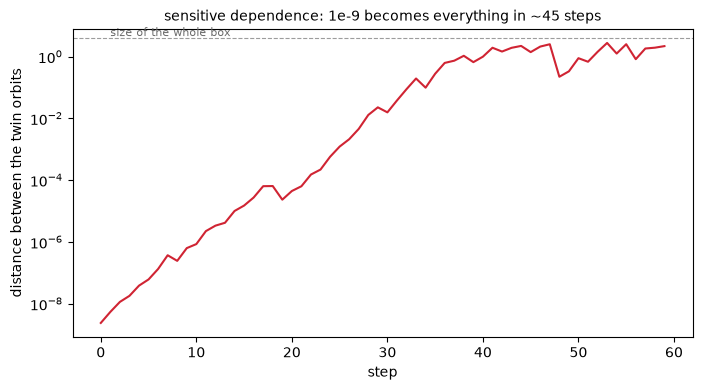

In [3]:
# two orbits born a billionth apart: the distance between them, step by step
x1, y1 = 0.1, 0.1
x2, y2 = 0.1 + 1e-9, 0.1
distances = []
for _ in range(60):
    x1, y1 = np.sin(a * y1) - np.cos(b * x1), np.sin(c * x1) - np.cos(d * y1)
    x2, y2 = np.sin(a * y2) - np.cos(b * x2), np.sin(c * x2) - np.cos(d * y2)
    distances.append(np.hypot(x1 - x2, y1 - y2))

fig, ax = plt.subplots(figsize=(8, 4))
ax.semilogy(distances, color="#D02433", lw=1.5)
ax.axhline(4, color="#9C9C9C", lw=0.8, ls="--")
ax.text(1, 4.6, "size of the whole box", fontsize=8, color="#6B6B6B")
ax.set_xlabel("step")
ax.set_ylabel("distance between the twin orbits")
ax.set_title("sensitive dependence: 1e-9 becomes everything in ~45 steps",
             fontsize=10)
plt.show()

The climb is a straight line on the log axis until it hits the ceiling: the separation multiplies by a roughly constant factor *every step* (exponential growth, the same law as chapter 8's escapes, now acting on the gap between twins rather than on the orbit itself). After about 45 steps the two orbits are as far apart as the box allows, and from then on they are strangers, each wandering the same attractor with no memory of having been twins. This is **sensitive dependence on initial conditions** (empfindliche Abhängigkeit von den Anfangsbedingungen), the defining property of chaos, and it is why Lorenz's three-decimal shortcut rewrote his weather.

Hold both truths at once, because the artwork lives between them: *individually* the orbit is unpredictable beyond a few dozen steps, yet *statistically* it is utterly reliable: every orbit paints the same figure. Chaos destroys the trajectory and preserves the shape.

## A million visits: density is the object

A scatter plot spends its beauty quickly: at a hundred thousand dots the veils clot into solid orange, because a scatter can only say *visited or not*. But the attractor's anatomy is in *how often*: some seams are visited a thousand times more than the faint bays beside them. The right object is not the set of points but a **census of visits**: chop the box into a grid of small cells and count the landings per cell.

NumPy has this census as a single call, and it is worth learning properly because half of Part V will quietly rely on it. `np.histogram2d(x, y, bins, range)` takes the x-coordinates and y-coordinates of any cloud of points and returns a 2D array of counts: element $[i, j]$ holds how many points fell into cell $[i, j]$. Two habits to fix immediately, both demonstrated below: the first axis of the counts array follows x (so we transpose with `.T` before `imshow`, which wants rows to be y), and passing an explicit `range` keeps the grid identical from run to run whether or not a stray point lands near the edge.

In [4]:
# np.histogram2d in miniature: six points, a 4x4 grid, counts you can check
demo_x = np.array([0.5, 0.6, 0.55, 2.5, 2.6, 3.5])
demo_y = np.array([0.5, 0.4, 0.60, 1.5, 1.4, 3.5])
counts, x_edges, y_edges = np.histogram2d(demo_x, demo_y, bins=4,
                                          range=[[0, 4], [0, 4]])
print("counts, printed with x as rows (as returned):")
print(counts.astype(int))
print()
print("three points near (0.5, 0.5), two near (2.5, 1.5), one at (3.5, 3.5)")

counts, printed with x as rows (as returned):
[[3 0 0 0]
 [0 0 0 0]
 [0 2 0 0]
 [0 0 0 1]]

three points near (0.5, 0.5), two near (2.5, 1.5), one at (3.5, 3.5)


Read the printed array against the comment below it: the cluster of three sits at `counts[0, 0]` (first x-cell, first y-cell), the pair at `counts[2, 1]`. The convention takes one cup of coffee to absorb and then never surprises you again; the call returns in chapters 23, 25 and 27, each time as exactly this census-then-colormap move.

Now the real census. One orbit of twelve million steps would work, but there is a faster route that NumPy prefers: iterate **two hundred thousand orbits in lockstep**, each from its own random start (chapter 2's seeded generator hands them out), as arrays $x$ and $y$ that hop together. An honesty note before the code, because the picture this makes is *exactly* the same attractor: we are not changing the mathematics, only visiting the figure with a crowd instead of a lone walker. Each of the 200,000 walkers needs a short **warm-up** (Einschwingphase) of discarded steps while it falls from its random birthplace onto the attractor; counting those transient steps would smear stray dust over the figure. After the warm-up, every further step of every walker is a legitimate visit, and we bin them all.

In [5]:
# the vectorized gatherer: 200,000 walkers, 100 warm-up steps, 60 counted ones
def dejong_census(a, b, c, d, quality=1.0, bins=800, seed=9):
    """Accumulate visit counts for the de Jong attractor.

    quality scales the sample budget: 1.0 means 200k walkers x 60 steps
    (12 million visits), 0.25 a quick look, 4.0 a print run.
    """
    rng = np.random.default_rng(seed)
    n_walkers = int(200_000 * quality)
    x = rng.uniform(-2, 2, n_walkers)
    y = rng.uniform(-2, 2, n_walkers)
    counts = np.zeros((bins, bins))
    for step in range(100 + 60):
        x, y = np.sin(a * y) - np.cos(b * x), np.sin(c * x) - np.cos(d * y)
        if step >= 100:                     # warm-up over: these visits count
            h, _, _ = np.histogram2d(x, y, bins=bins,
                                     range=[[-2.1, 2.1], [-2.1, 2.1]])
            counts += h
    return counts

census = dejong_census(a, b, c, d)
print(f"{census.sum():,.0f} visits counted")
print(f"busiest cell: {census.max():,.0f} visits; "
      f"empty cells: {(census == 0).mean():.0%} of the grid")

12,000,000 visits counted
busiest cell: 5,580 visits; empty cells: 36% of the grid


Twelve million visits, and the busiest single cell took thousands of them while most of the grid took none. That spread is the problem the next cell solves. Mapped straight to a colormap, a handful of blazing cells would use up the entire bright end and everything else would sit in the bottom few percent: near-black, structure lost. The cure is the logarithm again (it already earned its keep in the sensitivity plot, and chapter 8's smooth-coloring exercise leaned on it too): `np.log1p(counts)`, which is $\ln(1 + \text{counts})$, compresses thousands-to-one ratios into a range a colormap can spend sensibly, and its built-in $+1$ politely maps empty cells to exactly zero, keeping the ground truly dark.

The colormap itself is the same judgment call as chapter 8's four-panel comparison: the counts are the structure, the colormap is the mood. Attractors, like fractals, tend to reward darkness: the figure is made of *light* (accumulated visits), and light reads best against night.

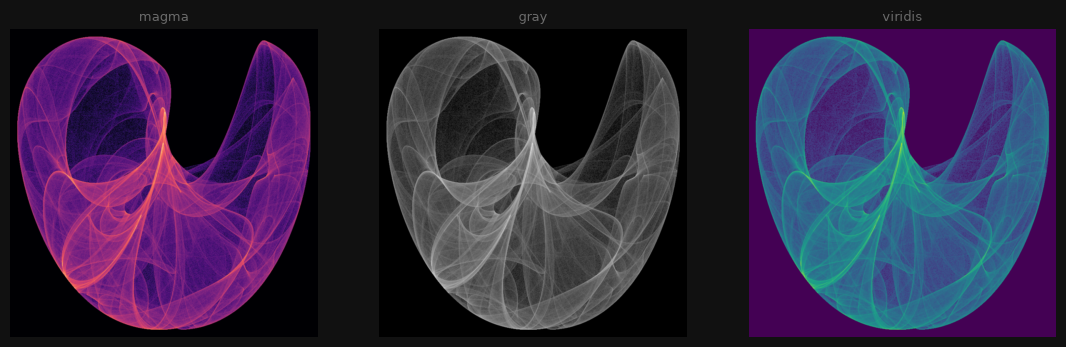

In [6]:
# density -> log1p -> colormap: the attractor as long-exposure photograph
def show_census(census, cmap="magma", ax=None, title=None):
    img = np.log1p(census).T                # log tames the range; .T flips x/y
    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 7))
    ax.imshow(img, origin="lower", cmap=cmap, interpolation="bilinear")
    ax.axis("off")
    if title:
        ax.set_title(title, fontsize=9, color="#6B6B6B")

fig, axes = plt.subplots(1, 3, figsize=(13.5, 4.6), facecolor="#111111")
for ax, cmap in zip(axes, ["magma", "gray", "viridis"]):
    show_census(census, cmap=cmap, ax=ax, title=cmap)
plt.show()

**Look and compare.** Same census three times. `magma` reads as smoke lit from below, `gray` as a long-exposure photograph from some impossible observatory, `viridis` as scientific instrumentation. And notice what the logarithm rescued: the faint outer veils, thousands of times less visited than the seams, are *there* in all three panels. Comment out the `np.log1p` (replace `img` with `census.T`) and rerun to see what the raw counts look like: a few white-hot threads on black, the rest of the anatomy gone.

**Try it.** `bins=800` decides the grain. Drop to 200: the figure goes soft, like a photograph enlarged past its resolution. The census machinery does not care; only the census's *display* does.

## The parameter safari

Four numbers, one picture each: the de Jong family is less a formula than a continent, and $(a, b, c, d)$ are coordinates in it. Below, four documented locations (all four circulate in Paul Bourke's archive, the genre's herbarium) plus one deliberately dull one. The names are ours; the continent has no signposts.

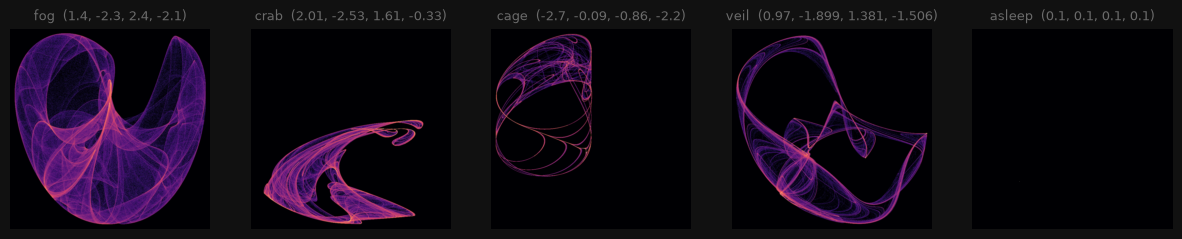

In [7]:
# five expeditions: four strange attractors and one that is not
PRESETS = {
    "fog":    (1.4, -2.3, 2.4, -2.1),       # today's house parameters
    "crab":   (2.01, -2.53, 1.61, -0.33),
    "cage":   (-2.7, -0.09, -0.86, -2.2),
    "veil":   (0.970, -1.899, 1.381, -1.506),
    "asleep": (0.1, 0.1, 0.1, 0.1),         # the dull control
}

fig, axes = plt.subplots(1, 5, figsize=(15, 3.4), facecolor="#111111")
for ax, (name, params) in zip(axes, PRESETS.items()):
    show_census(dejong_census(*params, quality=0.25), cmap="magma",
                ax=ax, title=f"{name}  {params}")
plt.show()

**Look and compare.** Four strange attractors, four unrelated anatomies: billowing fog, a swept claw, a wiry cage, a hanging veil, all from the same two lines of trigonometry. And then the fifth panel: at $(0.1, 0.1, 0.1, 0.1)$ every walker slides into the same single point and stays, a **fixed point** (Fixpunkt), the census a lone white dot. That dull panel is the most instructive of the five. Chaos is not what iteration *does*; it is a special condition that some parameters reach and most do not. The continent is mostly desert (fixed points and short repeating cycles), threaded with regions where the folding becomes intricate enough to trap orbits in endless novelty. Finding the good regions is prospecting, and exercise (c) hands you the pan.

**Try it.** Nudge one number of `fog` by 0.05 and rerun. Some nudges redecorate the figure; some collapse it entirely. (After the sensitivity demo, this should feel familiar: parameter space, too, has its butterflies.)

## Export your artwork

Pick a preset (or your own four numbers), a colormap, and a sample budget. Replace `yourname` and run; the census lands in the gallery folder at print quality.

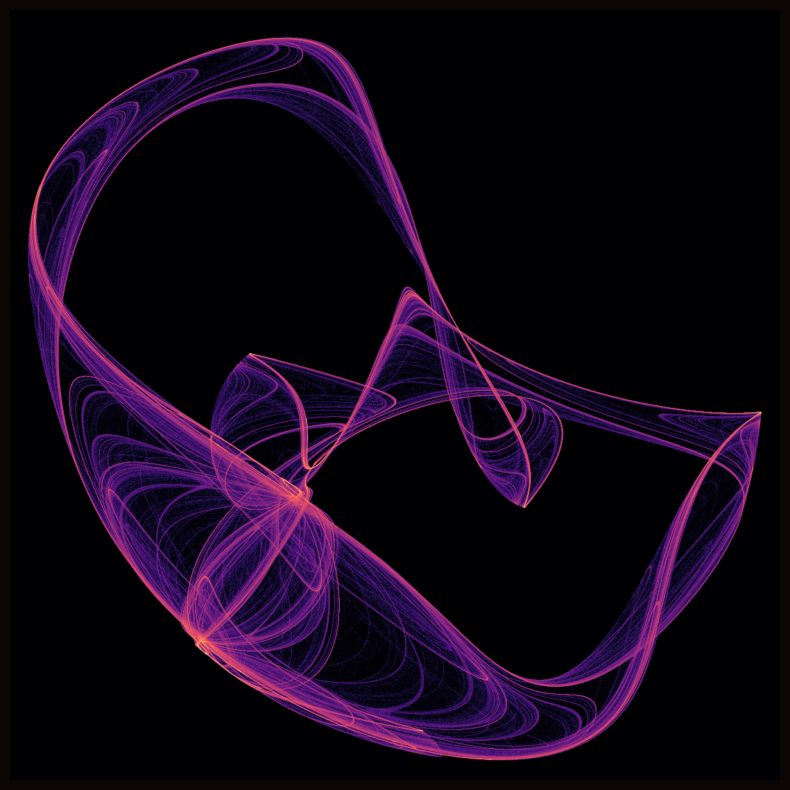

saved: assets/outputs/ch09_yourname.png


In [8]:
# save YOUR attractor: choose parameters and colormap, replace 'yourname'
my_census = dejong_census(*PRESETS["veil"], quality=1.0, bins=1200, seed=2)
my_artwork, my_ax = plt.subplots(figsize=(10, 10), facecolor="#0B0604")
show_census(my_census, cmap="magma", ax=my_ax)
plt.show()
saved_path = save_artwork(my_artwork, "yourname", chapter=9)

## Exercises

**(a) Parameter exploration: one valley of the continent.** Fix $c = 2.4$ and $d = -2.1$ (the `fog` values) and render a 3 by 3 grid sweeping $a$ over $\{1.2, 1.4, 1.6\}$ and $b$ over $\{-2.5, -2.3, -2.1\}$ at `quality=0.1`. Describe the families you see: which neighbors are clearly relatives, and where does the character break? One sentence per row is plenty.

**(b) Code modification: the Clifford attractor.** Peter de Jong's map has a sibling, attributed to Clifford Pickover:

$$x' = \sin(a\,y) + c\cdot\cos(a\,x), \qquad y' = \sin(b\,x) + d\cdot\cos(b\,y).$$

Note the differences: the second term is *scaled* by $c$ or $d$ rather than driven by them, and each line reuses one parameter twice. Write `clifford_census` (one formula swap in the gatherer; mind the wider range: coordinates can now reach $\pm(1 + |c|)$ and $\pm(1 + |d|)$) and render the documented set $(-1.4, 1.6, 1.0, 0.7)$.

<details><summary>Solution</summary>

```python
def clifford_census(a, b, c, d, quality=1.0, bins=800, seed=9):
    rng = np.random.default_rng(seed)
    n_walkers = int(200_000 * quality)
    x = rng.uniform(-2, 2, n_walkers)
    y = rng.uniform(-2, 2, n_walkers)
    reach_x, reach_y = 1 + abs(c), 1 + abs(d)
    counts = np.zeros((bins, bins))
    for step in range(100 + 60):
        x, y = (np.sin(a * y) + c * np.cos(a * x),
                np.sin(b * x) + d * np.cos(b * y))
        if step >= 100:
            h, _, _ = np.histogram2d(x, y, bins=bins,
                                     range=[[-reach_x, reach_x],
                                            [-reach_y, reach_y]])
            counts += h
    return counts

fig, ax = plt.subplots(figsize=(7, 7), facecolor="#111111")
show_census(clifford_census(-1.4, 1.6, 1.0, 0.7), cmap="magma", ax=ax)
plt.show()
```

The Clifford family tends toward blockier, more architectural figures than de Jong's veils; with $(-1.4, 1.6, 1.0, 0.7)$ you should see a folded ribbon with four dense knots. The only genuine trap is the `range`: reuse de Jong's $\pm 2.1$ box and the figure gets cropped mid-wing.
</details>

**(c) Creative challenge: prospecting.** Draw four numbers at random from $[-3, 3]$ (seed your generator, chapter 2, so you can refind what you find), render at `quality=0.1`, and repeat until something strange looks back. Expect mostly desert: dots, rings, thin scribbles. When an attractor appears, render it at full quality, name the creature, and export it with `save_artwork`. Keep the numbers in the filename or a comment; discoverers who lose their coordinates have to rediscover them the hard way.

## Further reading

- Edward N. Lorenz, "Deterministic Nonperiodic Flow", *Journal of the Atmospheric Sciences* 20, no. 2 (1963): 130-141: the founding paper, and unusually readable as founding papers go; the attractor figures are hand-plotted.
- James Gleick, *Chaos: Making a New Science* (Viking, 1987): the book that made Lorenz's printout famous; chapter 1 tells the LGP-30 story at full length.
- A. K. Dewdney, "Probing the strange attractions of chaos", *Scientific American* 257, no. 1 (July 1987): the column that printed Peter de Jong's formula, and a period piece of the readers-with-home-computers culture this chapter descends from.
- Clifford A. Pickover, *Computers, Pattern, Chaos and Beauty* (St. Martin's Press, 1990): recipes and exhortations from the genre's most prolific popularizer.
- Paul Bourke's attractor pages at paulbourke.net (begun 1989): the living archive of parameter sets, including the de Jong and Clifford galleries this chapter's presets come from.

---
### Appendix: regenerate the showpiece

This last cell (re)creates the image at the top of the notebook: the `fog` parameters, 48 million visits (quality 4) on a 2000 by 2000 census, rendered through a custom four-stop ember colormap: near-black, deep rust, ember orange, pale gold. It runs automatically with *Restart & Run All* and takes about 15 seconds.

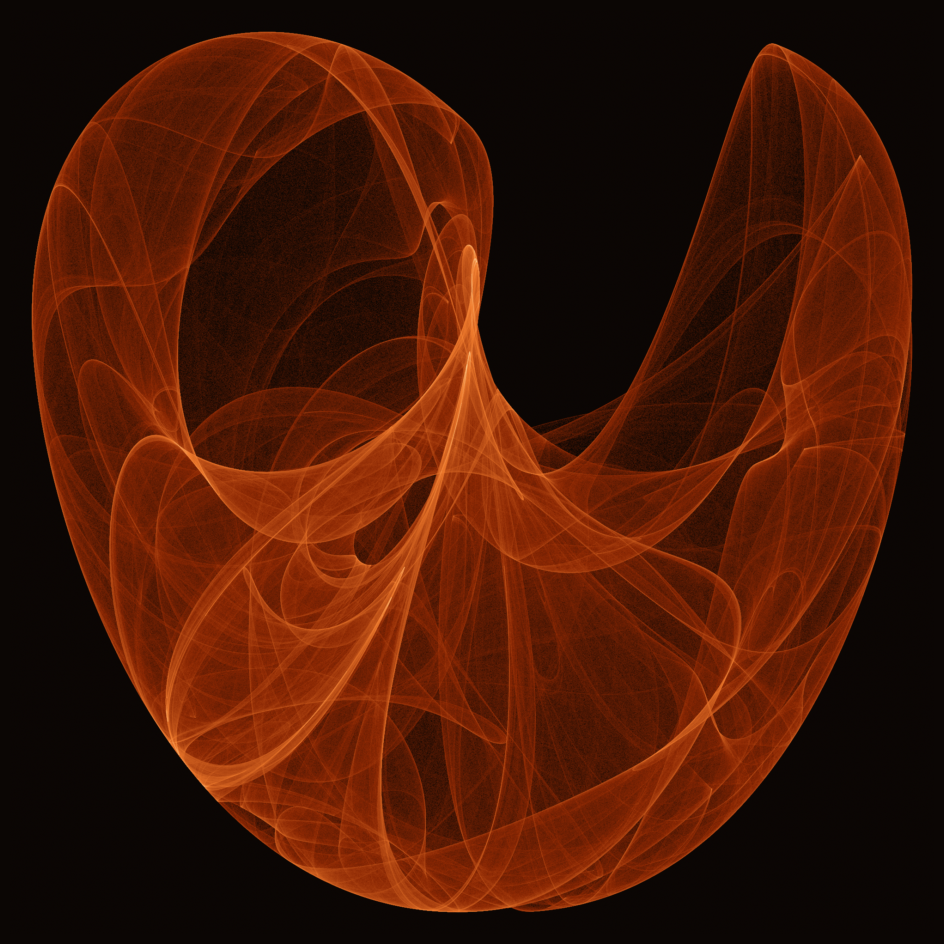

saved: assets/outputs/ch09_showpiece.png


In [9]:
# regenerate this chapter's showpiece: fog, 48 million visits, ember light
from matplotlib.colors import LinearSegmentedColormap

EMBER = LinearSegmentedColormap.from_list(
    "ember", ["#0B0604", "#8C2703", "#F07B2D", "#FFE8B0"])

sp_census = dejong_census(*PRESETS["fog"], quality=4.0, bins=2000, seed=9)
showpiece, sp_ax = plt.subplots(figsize=(12, 12), facecolor="#0B0604")
show_census(sp_census, cmap=EMBER, ax=sp_ax)
plt.show()
saved_path = save_artwork(showpiece, "showpiece", chapter=9)